In [322]:
import numpy as np
import pandas as pd


df = pd.read_csv("data/car_price.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [323]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [324]:
df.shape

(8128, 13)

In [325]:
df.drop_duplicates(inplace=True)

In [326]:
df.shape

(6926, 13)

In [327]:
import re


columns_for_check = ['mileage','engine','max_power']
df_check_unique = df[columns_for_check].copy()
for column in columns_for_check:
    print("Уникальные единицы измерения для ",column, ":")
    df_check_unique[column] = df_check_unique[column].str.extract(r'([a-zA-Z]+/?[a-zA-Z]*)')
    print(df_check_unique[column].unique())
print("Уникальные значения для столбца torque : \n",df['torque'].unique())


Уникальные единицы измерения для  mileage :
['kmpl' 'km/kg' nan]
Уникальные единицы измерения для  engine :
['CC' nan]
Уникальные единицы измерения для  max_power :
['bhp' nan]
Уникальные значения для столбца torque : 
 ['190Nm@ 2000rpm' '250Nm@ 1500-2500rpm' '12.7@ 2,700(kgm@ rpm)'
 '22.4 kgm at 1750-2750rpm' '11.5@ 4,500(kgm@ rpm)' '113.75nm@ 4000rpm'
 '7.8@ 4,500(kgm@ rpm)' '59Nm@ 2500rpm' '170Nm@ 1800-2400rpm'
 '160Nm@ 2000rpm' '248Nm@ 2250rpm' '78Nm@ 4500rpm' nan '84Nm@ 3500rpm'
 '115Nm@ 3500-3600rpm' '200Nm@ 1750rpm' '62Nm@ 3000rpm'
 '219.7Nm@ 1500-2750rpm' '114Nm@ 3500rpm' '115Nm@ 4000rpm' '69Nm@ 3500rpm'
 '172.5Nm@ 1750rpm' '6.1kgm@ 3000rpm' '114.7Nm@ 4000rpm' '60Nm@ 3500rpm'
 '90Nm@ 3500rpm' '151Nm@ 4850rpm' '104Nm@ 4000rpm' '320Nm@ 1700-2700rpm'
 '250Nm@ 1750-2500rpm' '145Nm@ 4600rpm' '146Nm@ 4800rpm'
 '343Nm@ 1400-3400rpm' '200Nm@ 1400-3400rpm' '200Nm@ 1250-4000rpm'
 '400Nm@ 2000-2500rpm' '138Nm@ 4400rpm' '360Nm@ 1200-3400rpm'
 '200Nm@ 1200-3600rpm' '380Nm@ 1750-2500rpm' '17

In [328]:
#Разбиение на число и единицу измерения
for column in columns_for_check:
    df[f'{column}_num'] = df[column].str.extract(r'([0-9]+\.?[0-9]*)')
    df[f'{column}_unit'] = df[column].str.extract(r'([a-zA-Z]+/?[a-zA-Z]*)')
    df[f'{column}_num'] = pd.to_numeric(df[f'{column}_num'], errors='coerce')

Сложнее всего с torque

In [329]:
def parse_torque(torque_str):
    if pd.isna(torque_str):
        return pd.Series([None, None, None])

    # Убираем лишние пробелы и приводим к нижнему регистру
    torque_str = torque_str.strip().lower()

    # Ищем первое число
    num1_match = re.search(r'([\d\.]+)', torque_str)
    torque_num1 = float(num1_match.group(1)) if num1_match else None

    # Ищем единицу измерения крутящего момента
    if 'kgm' in torque_str or 'k gm' in torque_str or 'kg m' in torque_str:
        torque_unit1 = 'kgm'
    elif 'nm' in torque_str or 'n m' in torque_str:
        torque_unit1 = 'nm'
    else:
        torque_unit1 = None

    # Ищем последнее число (rpm)
    rpm_matches = re.findall(r'(\d{3,})', torque_str.replace(',', ''))
    torque_num2 = int(rpm_matches[-1]) if rpm_matches else None


    return pd.Series([torque_num1, torque_unit1, torque_num2])
df[['torque_num1', 'torque_unit1', 'rpm']] = df['torque'].apply(parse_torque)
print(df[['torque','torque_num1', 'torque_unit1', 'rpm','engine_num','engine_unit','mileage_num','mileage_unit','max_power_num','max_power_unit']].head())

                     torque  torque_num1 torque_unit1     rpm  engine_num  \
0            190Nm@ 2000rpm        190.0           nm  2000.0      1248.0   
1       250Nm@ 1500-2500rpm        250.0           nm  2500.0      1498.0   
2     12.7@ 2,700(kgm@ rpm)         12.7          kgm  2700.0      1497.0   
3  22.4 kgm at 1750-2750rpm         22.4          kgm  2750.0      1396.0   
4     11.5@ 4,500(kgm@ rpm)         11.5          kgm  4500.0      1298.0   

  engine_unit  mileage_num mileage_unit  max_power_num max_power_unit  
0          CC        23.40         kmpl          74.00            bhp  
1          CC        21.14         kmpl         103.52            bhp  
2          CC        17.70         kmpl          78.00            bhp  
3          CC        23.00         kmpl          90.00            bhp  
4          CC        16.10         kmpl          88.20            bhp  


In [330]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,...,seats,mileage_num,mileage_unit,engine_num,engine_unit,max_power_num,max_power_unit,torque_num1,torque_unit1,rpm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,...,5.0,23.40,kmpl,1248.0,CC,74.00,bhp,190.0,nm,2000.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,...,5.0,21.14,kmpl,1498.0,CC,103.52,bhp,250.0,nm,2500.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,...,5.0,17.70,kmpl,1497.0,CC,78.00,bhp,12.7,kgm,2700.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,...,5.0,23.00,kmpl,1396.0,CC,90.00,bhp,22.4,kgm,2750.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,...,5.0,16.10,kmpl,1298.0,CC,88.20,bhp,11.5,kgm,4500.0


In [331]:
print(df['fuel'].unique())
print(df['transmission'].unique())
print(df['owner'].unique())
print(df['seller_type'].unique())
print(df['mileage_unit'].unique())
print(df['engine_unit'].unique())
print(df['max_power_unit'].unique())
print(df['torque_unit1'].unique())


['Diesel' 'Petrol' 'LPG' 'CNG']
['Manual' 'Automatic']
['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']
['Individual' 'Dealer' 'Trustmark Dealer']
['kmpl' 'km/kg' nan]
['CC' nan]
['bhp' nan]
['nm' 'kgm' None nan]


Ко всем категориальным признакам кроме owner - применим one-hot encoder

nm переводится в kgm
1 kgm = 9.80665 nm


kmpl переводится в km/kg
1 kmpl = 1.35 km/kg


Так как единицы измерения разные, а количество пропусков меньше 5%, то проще будет их удалить, чем агрегировать

In [332]:
shape1 = df.shape
df.dropna(inplace=True)
shape2 = df.shape
print(f"Количество удаленных строк = {shape1[0]-shape2[0]};\n {round(100*(shape1[0]-shape2[0])/shape1[0],2)}%")

Количество удаленных строк = 219;
 3.16%


In [333]:
#приведем к одним единицам измерения
df["mileage_num"] = df['mileage_num'].where(
    df["mileage_unit"] == "km/kg", 
    df['mileage_num'] * 1.35
)

df["torque_num1"] = df['torque_num1'].where(
    df["torque_unit1"] == "nm", 
    df['torque_num1'] * 0.1019716213
)
df.drop(columns=["mileage_unit","torque_unit1","max_power_unit","engine_unit"], inplace=True)

In [334]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


df.drop(columns=['name'], inplace=True)

    
columns_for_check.append("torque")
df.drop(columns=columns_for_check, inplace=True)

# Заполнение пропусков медианой для числовых признаков (Если вдруг остались)
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

    
# Обработка выбросов с помощью IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

# Кодирование категориальных признаков
# Label Encoding для 'owner' (с учетом порядка)
owner_mapping = {
    'First Owner': 0,
    'Second Owner': 1,
    'Third Owner': 2,
    'Fourth & Above Owner': 3,
    'Test Drive Car': 4
}
df['owner'] = df['owner'].map(owner_mapping).fillna(4)  # Неизвестные значения заменяются на 4

# - One-Hot Encoding для остальных категориальных признаков
df = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', ], drop_first=True)

# # Масштабирование числовых признаков
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


# Разделение на train/test
X = df.drop('selling_price', axis=1)
y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Предобработка завершена. Размеры выборок:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Предобработка завершена. Размеры выборок:
X_train: (5365, 15), X_test: (1342, 15)
y_train: (5365,), y_test: (1342,)


In [335]:
df.head()

,year,selling_price,km_driven,owner,seats,mileage_num,engine_num,max_power_num,torque_num1,rpm,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,0.093226,-0.101839,1.695783,0,0.0,1.008720,-0.319950,-0.455633,0.377807,-1.155221,True,False,False,True,False,True
1,0.093226,-0.369677,1.110941,1,0.0,0.436692,0.404512,0.649193,1.068365,-0.598342,True,False,False,True,False,True
2,-2.016488,-1.079447,1.569640,2,0.0,-0.434006,0.401614,-0.305928,-1.794056,-0.375590,False,False,True,True,False,True
3,-0.961631,-0.855133,1.271486,0,0.0,0.907476,0.108931,0.143189,-1.782672,-0.319902,True,False,False,True,False,True
4,-1.752774,-1.173191,1.110941,0,0.0,-0.838981,-0.175058,0.075821,-1.795464,1.629176,False,False,True,True,False,True


In [336]:
#Построение линейной регрессии
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Обучение модели
model = LinearRegression()
model.fit(X_train, y_train)

# Предсказания
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


In [337]:
# Метрики
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("Train Metrics:")
print(f"MAE: {mae_train:.4f}, RMSE: {rmse_train:.4f}, R2: {r2_train:.4f}")

print("Test Metrics:")
print(f"MAE: {mae_test:.4f}, RMSE: {rmse_test:.4f}, R2: {r2_test:.4f}")

Train Metrics:
MAE: 0.3733, RMSE: 0.4896, R2: 0.7622
Test Metrics:
MAE: 0.3708, RMSE: 0.4863, R2: 0.7555


In [338]:
X_scale = np.arange(len(y_test))

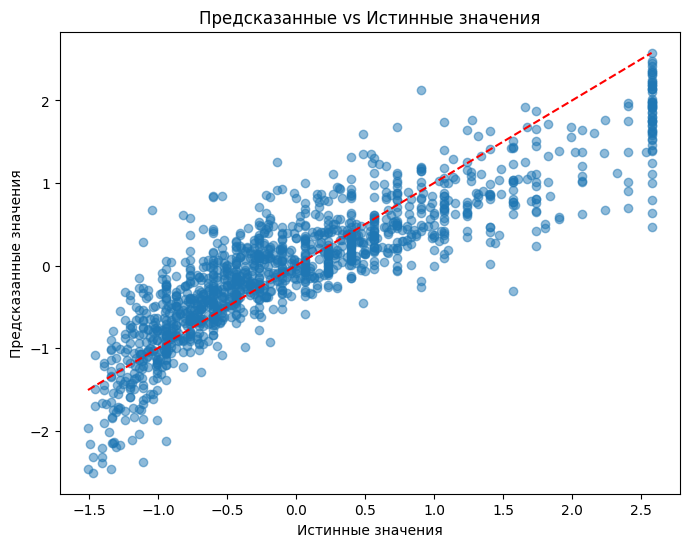

In [339]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Предсказанные vs Истинные значения")
plt.show()

In [340]:
#Регуляризация  
from sklearn.linear_model import Ridge, Lasso, ElasticNet

alphas = np.logspace(-4, 2, 50)

ridge_metrics = {'mae': [], 'rmse': [], 'r2': []}
lasso_metrics = {'mae': [], 'rmse': [], 'r2': []}
elastic_metrics = {'mae': [], 'rmse': [], 'r2': []}

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    lasso = Lasso(alpha=alpha, max_iter=5000)
    elastic = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=5000)

    for model, metrics in zip([ridge, lasso, elastic],
                              [ridge_metrics, lasso_metrics, elastic_metrics]):
        mae_scores, rmse_scores, r2_scores = [], [], []
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        r2_scores.append(r2_score(y_test, y_pred))

        metrics['mae'].append(np.mean(mae_scores))
        metrics['rmse'].append(np.mean(rmse_scores))
        metrics['r2'].append(np.mean(r2_scores))

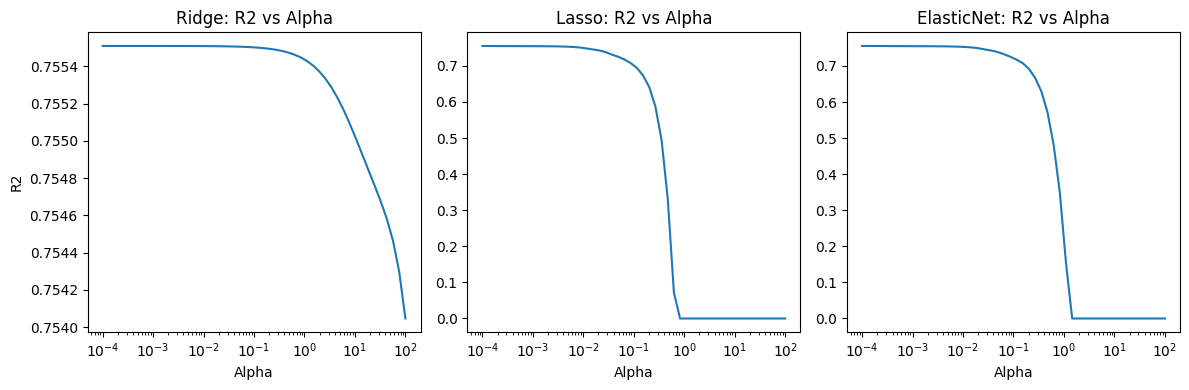

In [341]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(alphas, ridge_metrics['r2'], label='Ridge')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R2')
plt.title('Ridge: R2 vs Alpha')

plt.subplot(1, 3, 2)
plt.plot(alphas, lasso_metrics['r2'], label='Lasso')
plt.xscale('log')
plt.xlabel('Alpha')
plt.title('Lasso: R2 vs Alpha')

plt.subplot(1, 3, 3)
plt.plot(alphas, elastic_metrics['r2'], label='ElasticNet')
plt.xscale('log')
plt.xlabel('Alpha')
plt.title('ElasticNet: R2 vs Alpha')

plt.tight_layout()
plt.show()

In [342]:
best_alpha = alphas[np.argmax(lasso_metrics['r2'])]
lasso_best = Lasso(alpha=best_alpha, max_iter=5000)
lasso_best.fit(X_train, y_train)

# Признаки с нулевыми коэффициентами
zero_coef = X_train.columns[lasso_best.coef_ == 0]
print("Признаки, зануленные Lasso:", zero_coef.tolist())

Признаки, зануленные Lasso: ['seats']


Обнулены seats (там всегда число 5.0)

In [ ]:
#Полиноминальные признаки
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge_poly = Ridge(alpha=best_alpha)
ridge_poly.fit(X_train_poly, y_train)

y_pred_poly = ridge_poly.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("Полиномиальная модель (Ridge) для второй степени полиноминальных признаков:")
print(f"MAE: {mae_poly:.4f}, RMSE: {rmse_poly:.4f}, R2: {r2_poly:.4f}")

poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge_poly = Ridge(alpha=best_alpha)
ridge_poly.fit(X_train_poly, y_train)

y_pred_poly = ridge_poly.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("Полиномиальная модель (Ridge) для третьей степени полиноминальных признаков:")
print(f"MAE: {mae_poly:.4f}, RMSE: {rmse_poly:.4f}, R2: {r2_poly:.4f}")


Полиномиальная модель (Ridge) для второй степени полиноминальных признаков:
MAE: 0.2910, RMSE: 0.4008, R2: 0.8339
Полиномиальная модель (Ridge) для третьей степени полиноминальных признаков:
MAE: 0.2782, RMSE: 0.4384, R2: 0.8013


In [348]:
# Подбор гиперпараметров
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


param_grid = [
    # Для Ridge
    {
        'poly__degree': [1, 2],
        'model': [Ridge()],
        'model__alpha': np.logspace(-4, 1, 10)
    },
    # Для Lasso
    {
        'poly__degree': [1, 2],
        'model': [Lasso(max_iter=5000)],
        'model__alpha': np.logspace(-4, 1, 10)
    },
    # Для ElasticNet
    {
        'poly__degree': [1, 2],
        'model': [ElasticNet(max_iter=5000)],
        'model__alpha': np.logspace(-4, 1, 10),
        'model__l1_ratio': [0.1, 0.5, 0.9]
    }
]

pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('model', 'passthrough')  # временная заглушка
])

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший R2:", grid.best_score_)

# Предсказания с лучшей моделью
y_pred_best = grid.predict(X_test)
print("Тестовый R2:", r2_score(y_test, y_pred_best))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Лучшие параметры: {'model': Ridge(), 'model__alpha': np.float64(10.0), 'poly__degree': 2}
Лучший R2: 0.8443032210830126
Тестовый R2: 0.835659871825853
